1. Given a CSV file containing Zomato restaurant ratings, use pandas to detect outliers in the 'user_rating' column using the IQR method and print the indices of the detected outliers.


In [2]:
import pandas as pd

df = pd.read_csv("zomato_ratings.csv")

Q1 = df["user_rating"].quantile(0.25)
Q3 = df["user_rating"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["user_rating"] < lower_bound) |
    (df["user_rating"] > upper_bound)
]

print("Outlier indices:")
print(outliers.index.tolist())

Outlier indices:
[]


2. Create a boxplot for the 'order_amount' column from a Swiggy orders dataset using matplotlib, and visually identify any outliers present.<br><br><em><strong>Hint:</strong> Use plt.boxplot() and label your axes for clarity.</em>


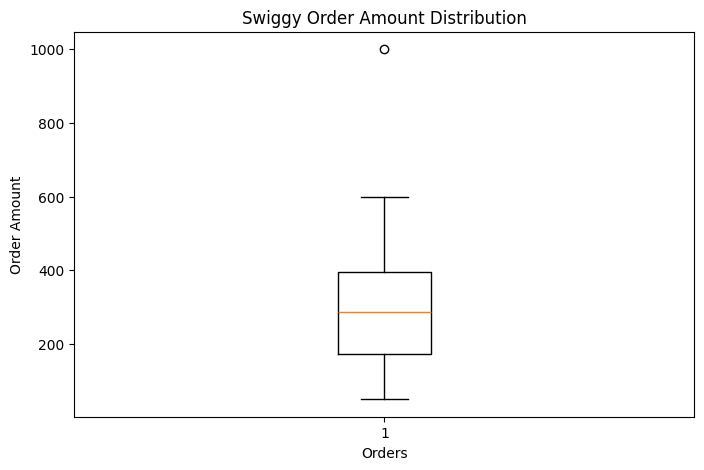

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("swiggy_orders.csv")

order_amount = df["order_amount"]

plt.figure(figsize=(8, 5))
plt.boxplot(order_amount, vert=True)

plt.title("Swiggy Order Amount Distribution")
plt.ylabel("Order Amount")
plt.xlabel("Orders")

plt.show()

3. Apply winsorization to the 'transaction_amount' column in a Paytm transactions DataFrame to cap all values above the 95th percentile and below the 5th percentile, then display the updated column statistics.


In [4]:
import pandas as pd

df = pd.DataFrame({
    "transaction_id": range(1, 11),
    "transaction_amount": [50, 120, 200, 250, 300, 400, 500, 1000, 5000, 8000]
})

lower_bound = df["transaction_amount"].quantile(0.05)
upper_bound = df["transaction_amount"].quantile(0.95)

df["transaction_amount"] = df["transaction_amount"].clip(lower=lower_bound, upper=upper_bound)

print("Updated Statistics:")
print(df["transaction_amount"].describe())

Updated Statistics:
count      10.000000
mean     1450.150000
std      2352.698026
min        81.500000
25%       212.500000
50%       350.000000
75%       875.000000
max      6650.000000
Name: transaction_amount, dtype: float64


4. You have a DataFrame of Flipkart product prices stored as strings with currency symbols (e.g., '₹1,299'). Convert this column to numeric type using pandas, ensuring all non-numeric characters are removed.<br><br><em><strong>Hint:</strong> Use str.replace() and astype().</em>


In [6]:
import pandas as pd

df = pd.DataFrame({
    "product": ["Phone", "Laptop", "Headphones", "Watch", "Tablet"],
    "price": ["₹1,299", "₹45,999", "₹2,499", "₹5,999", "₹12,499"]
})

df["price"] = df["price"].str.replace("₹", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)

df["price"] = df["price"].astype(int)

print("Updated DataFrame:")
print(df)

print("\nData Types:")
print(df.dtypes)

Updated DataFrame:
      product  price
0       Phone   1299
1      Laptop  45999
2  Headphones   2499
3       Watch   5999
4      Tablet  12499

Data Types:
product    object
price       int64
dtype: object


5. Fix the following code snippet where the 'is_premium' column in a Spotify user DataFrame is a mix of boolean, string, and integer types. Convert the entire column to boolean type, treating 'True', 1, and 'yes' as True, and everything else as False.

In [7]:
import pandas as pd
\
df = pd.DataFrame({
    "user_id": [1, 2, 3, 4, 5, 6],
    "is_premium": [True, "True", 1, "yes", 0, "no"]
})

print("Before conversion:")
print(df)

df["is_premium"] = df["is_premium"].astype(str).str.lower().isin(["true", "1", "yes"])

print("\nAfter conversion:")
print(df)

print("\nData type:")
print(df.dtypes)

Before conversion:
   user_id is_premium
0        1       True
1        2       True
2        3          1
3        4        yes
4        5          0
5        6         no

After conversion:
   user_id  is_premium
0        1        True
1        2        True
2        3        True
3        4        True
4        5       False
5        6       False

Data type:
user_id       int64
is_premium     bool
dtype: object
